Title: DSC 680: Project 1: Creating Thirs Shot Strategy in Pickleball

Author: Matthew Heinen

Date: 31 October 2025

Modified By: Matthew Heinen

Description: This project reads in cleans and gathersa the essential data to train and evaluate predictive model predicting the proper shot selection to win a rally. There will be two models train one more complex for professional players, one less complex for amateur players.

# Project 2: Shotselection in Pickleball

# Connect to the PKLMart Database and collect data. 

In [73]:
# Connect to the pklmart database to confirm access
import psycopg2

conn = psycopg2.connect(
    host="pklmartdb.ckkvdwandqoa.us-east-1.rds.amazonaws.com",
    port=5432,
    dbname="postgres",
    user="mheinen",
    password="4A3FR21l(!"
)
cur = conn.cursor()
cur.execute("SELECT version();")
print(cur.fetchone())
cur.close()
conn.close()


('PostgreSQL 13.20 on x86_64-pc-linux-gnu, compiled by gcc (GCC) 7.3.1 20180712 (Red Hat 7.3.1-17), 64-bit',)


In [74]:
# Show all the tables in the database 
# only pklm.prd schema, 
conn = psycopg2.connect(
    host="pklmartdb.ckkvdwandqoa.us-east-1.rds.amazonaws.com",
    port=5432,
    dbname="postgres",
    user="mheinen",
    password="4A3FR21l(!"
)
cur = conn.cursor()
cur.execute("""
    SELECT table_schema, table_name
    FROM information_schema.tables
    WHERE table_type = 'BASE TABLE' AND table_schema = 'pklm_prd';
""")
tables = cur.fetchall()
for schema, table in tables:
    print(f"{schema}.{table}")
cur.close()
conn.close()

pklm_prd.ball_type_ref
pklm_prd.metrics_ref
pklm_prd.shot_temp
pklm_prd.player_dupr_hist
pklm_prd.shot
pklm_prd.cv_player_pos
pklm_prd.rally
pklm_prd.backfill
pklm_prd.match
pklm_prd.game
pklm_prd.team
pklm_prd.player
pklm_prd.model_info
pklm_prd.tournament
pklm_prd.baseline_metrics
pklm_prd.game_temp
pklm_prd.up_player_cw
pklm_prd.player_dupr
pklm_prd.shot_type_ref


In [75]:
# Read in the rally data from the database
import pandas as pd
# Establish a connection to the PostgreSQL database
conn = psycopg2.connect(
    host="pklmartdb.ckkvdwandqoa.us-east-1.rds.amazonaws.com",
    port=5432,
    dbname="postgres",
    user="mheinen",
    password="4A3FR21l(!"
)
query = "SELECT * FROM pklm_prd.rally;"
rally = pd.read_sql(query, conn)
conn.close()

# Preview the rally data
rally.head(5)

/var/folders/xv/q0156cqs67s40wbxq6_vfykr0000gn/T/ipykernel_19613/3773201166.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  rally = pd.read_sql(query, conn)


,rally_id,match_id,game_id,rally_nbr,srv_team_id,srv_player_id,rtrn_team_id,rtrn_player_id,ts_player_id,ts_type,...,rtrn_team_rs_player_id,rtrn_team_ls_player_id,ending_type,ending_player_id,lob_cnt,dink_cnt,maint_dtm,maint_app,create_dtm,create_app
0,R8968,M113,G208,6,T152,P202,T155,P70,P202,Drop,...,P70,P205,Other,N/A,0,0,2023-06-08 21:21:31.907499+00:00,aspancake,2023-06-08 21:21:31.907499+00:00,aspancake
1,R8963,M113,G208,1,T152,P202,T155,P70,N/A,Drop,...,P70,P205,Error,P203,0,0,2023-06-08 21:21:31.498346+00:00,aspancake,2023-06-08 21:21:31.498346+00:00,aspancake
2,R8964,M113,G208,2,T155,P70,T152,P202,P205,Drive,...,P203,P202,Error,P205,0,0,2023-06-08 21:21:31.669341+00:00,aspancake,2023-06-08 21:21:31.669341+00:00,aspancake
3,R8965,M113,G208,3,T155,P205,T152,P203,P205,Drop,...,P203,P202,Error,P203,0,2,2023-06-08 21:21:31.712699+00:00,aspancake,2023-06-08 21:21:31.712699+00:00,aspancake
4,R8966,M113,G208,4,T155,P205,T152,P202,P70,Drop,...,P203,P202,Winner,P205,0,0,2023-06-08 21:21:31.775415+00:00,aspancake,2023-06-08 21:21:31.775415+00:00,aspancake


In [76]:
#Show the shape of the rally data
rally.shape

(54058, 30)

In [77]:
# Show all the columns in the rally data
rally.columns

Index(['rally_id', 'match_id', 'game_id', 'rally_nbr', 'srv_team_id',
       'srv_player_id', 'rtrn_team_id', 'rtrn_player_id', 'ts_player_id',
       'ts_type', 'w_team_id', 'to_ind', 'to_team_id', 'rally_len',
       'srv_switch_ind', 'rtrn_switch_ind', 'srv_team_flipped_ind',
       'rtrn_team_flipped_ind', 'srv_team_rs_player_id',
       'srv_team_ls_player_id', 'rtrn_team_rs_player_id',
       'rtrn_team_ls_player_id', 'ending_type', 'ending_player_id', 'lob_cnt',
       'dink_cnt', 'maint_dtm', 'maint_app', 'create_dtm', 'create_app'],
      dtype='object')

In [78]:
# Remove unesecssary or irrelevant columns from the rally data
columns_to_keep = ['rally_id', 'rally_nbr' , 'srv_team_id',
       'srv_player_id', 'rtrn_team_id', 'rtrn_player_id', 'ts_player_id',
       'ts_type', 'w_team_id', 'rally_len',
       'srv_switch_ind', 'rtrn_switch_ind', 'srv_team_flipped_ind',
       'rtrn_team_flipped_ind', 'srv_team_rs_player_id',
       'srv_team_ls_player_id', 'rtrn_team_rs_player_id',
       'rtrn_team_ls_player_id']
rally = rally[columns_to_keep]
# Preview the filtered DF
rally.head(5)

,rally_id,rally_nbr,srv_team_id,srv_player_id,rtrn_team_id,rtrn_player_id,ts_player_id,ts_type,w_team_id,rally_len,srv_switch_ind,rtrn_switch_ind,srv_team_flipped_ind,rtrn_team_flipped_ind,srv_team_rs_player_id,srv_team_ls_player_id,rtrn_team_rs_player_id,rtrn_team_ls_player_id
0,R8968,6,T152,P202,T155,P70,P202,Drop,T152,14.0,Y,N,N,N,P203,P202,P70,P205
1,R8963,1,T152,P202,T155,P70,N/A,Drop,T155,13.0,Y,N,N,N,P203,P202,P70,P205
2,R8964,2,T155,P70,T152,P202,P205,Drive,T152,5.0,N,Y,N,N,P70,P205,P203,P202
3,R8965,3,T155,P205,T152,P203,P205,Drop,T155,8.0,N,Y,N,N,P70,P205,P203,P202
4,R8966,4,T155,P205,T152,P202,P70,Drop,T155,11.0,Y,Y,Y,N,P70,P205,P203,P202


In [79]:
# shot level data to get the location of the returns for all thirs shots to help train the model 
# Establish a connection to the PostgreSQL database
conn = psycopg2.connect(
    host="pklmartdb.ckkvdwandqoa.us-east-1.rds.amazonaws.com",
    port=5432,
    dbname="postgres",
    user="mheinen",
    password="4A3FR21l(!"
)
query = """
    SELECT shot_id, rally_id,  loc_x, loc_y, btt_before, shot_type, shot_type_orig
    FROM pklm_prd.shot
    WHERE shot_nbr = 3;
"""
shot_third = pd.read_sql(query, conn)
conn.close()
# Preview the third shot data
shot_third.head(5)

/var/folders/xv/q0156cqs67s40wbxq6_vfykr0000gn/T/ipykernel_19613/3480373998.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  shot_third = pd.read_sql(query, conn)


,shot_id,rally_id,loc_x,loc_y,btt_before,shot_type,shot_type_orig
0,S150129,R16839,12.30,19.75,0.4649,None,tsDrv
1,S150084,R16837,4.67,17.09,0.3325,None,tsDrp
2,S150102,R16838,2.92,23.24,0.5436,None,tsDrp
3,S436638,R52813,1.73,25.35,0.3583,None,tsDrv
4,S150146,R16841,2.66,21.68,0.3615,None,tsDrp


In [80]:
# find the percentage of missing values in the third shot data
missing_percentage = shot_third.isnull().mean() * 100
missing_percentage

shot_id            0.000000
rally_id           0.000000
loc_x              1.388625
loc_y              1.401269
btt_before         0.891333
shot_type         98.539731
shot_type_orig     0.000000
dtype: float64

In [81]:
# Remove shot_type from the third shot data due to high missing values
shot_third = shot_third.drop(columns=['shot_type'])

# Apply the average loc_x and loc_y and btt_before for missing values
shot_third['loc_x'].fillna(shot_third['loc_x'].mean(), inplace=True)
shot_third['loc_y'].fillna(shot_third['loc_y'].mean(), inplace=True)
shot_third['btt_before'].fillna(shot_third['btt_before'].mean(), inplace=True)

# find the percentage of missing values in the third shot data
missing_percentage = shot_third.isnull().mean() * 100
missing_percentage

shot_id           0.0
rally_id          0.0
loc_x             0.0
loc_y             0.0
btt_before        0.0
shot_type_orig    0.0
dtype: float64

In [82]:
# Drop shot_id from the third shot data as it is not needed for the merge
shot_third = shot_third.drop(columns=['shot_id'])

In [83]:
# find player specific data to train the model for relevancy against an oppontnt 
# Establish a connection to the PostgreSQL database
conn = psycopg2.connect(
    host="pklmartdb.ckkvdwandqoa.us-east-1.rds.amazonaws.com",
    port=5432,
    dbname="postgres",
    user="mheinen",
    password="4A3FR21l(!"
)
query = """
    SELECT player_id, gender, dom_hand
    FROM pklm_prd.player;
"""
player = pd.read_sql(query, conn)
conn.close()
# Preview the player data shape
player.shape

/var/folders/xv/q0156cqs67s40wbxq6_vfykr0000gn/T/ipykernel_19613/1958867211.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  player = pd.read_sql(query, conn)


(1077, 3)

In [84]:
# Use a vlookup type merge to get the player data into the rally df for each player
for col in ['srv_team_rs_player_id', 'srv_team_ls_player_id', 'rtrn_team_rs_player_id', 'rtrn_team_ls_player_id']:
    rally = rally.merge(
        player.rename(columns={'player_id': col, 'gender': f'{col}_gender', 'dom_hand': f'{col}_dom_hand'}),
        on=col,
        how='left'
    )
# Preview the merged DataFrame
rally.head(5)

,rally_id,rally_nbr,srv_team_id,srv_player_id,rtrn_team_id,rtrn_player_id,ts_player_id,ts_type,w_team_id,rally_len,...,rtrn_team_rs_player_id,rtrn_team_ls_player_id,srv_team_rs_player_id_gender,srv_team_rs_player_id_dom_hand,srv_team_ls_player_id_gender,srv_team_ls_player_id_dom_hand,rtrn_team_rs_player_id_gender,rtrn_team_rs_player_id_dom_hand,rtrn_team_ls_player_id_gender,rtrn_team_ls_player_id_dom_hand
0,R8968,6,T152,P202,T155,P70,P202,Drop,T152,14.0,...,P70,P205,M,R,F,R,F,R,M,R
1,R8963,1,T152,P202,T155,P70,N/A,Drop,T155,13.0,...,P70,P205,M,R,F,R,F,R,M,R
2,R8964,2,T155,P70,T152,P202,P205,Drive,T152,5.0,...,P203,P202,F,R,M,R,M,R,F,R
3,R8965,3,T155,P205,T152,P203,P205,Drop,T155,8.0,...,P203,P202,F,R,M,R,M,R,F,R
4,R8966,4,T155,P205,T152,P202,P70,Drop,T155,11.0,...,P203,P202,F,R,M,R,M,R,F,R


In [85]:
# Merge the shot third data with the rally data to get the loc_x and loc_y, btt_before for the third shot
# use a left join to keep all rally data
rally_ts = rally.merge(
    shot_third,
    on='rally_id',
    how='left' 
)
# Preview the merged DataFrame
rally_ts.head(5)

,rally_id,rally_nbr,srv_team_id,srv_player_id,rtrn_team_id,rtrn_player_id,ts_player_id,ts_type,w_team_id,rally_len,...,srv_team_ls_player_id_gender,srv_team_ls_player_id_dom_hand,rtrn_team_rs_player_id_gender,rtrn_team_rs_player_id_dom_hand,rtrn_team_ls_player_id_gender,rtrn_team_ls_player_id_dom_hand,loc_x,loc_y,btt_before,shot_type_orig
0,R8968,6,T152,P202,T155,P70,P202,Drop,T152,14.0,...,F,R,F,R,M,R,10.00,17.73,0.7656,tsDrp
1,R8963,1,T152,P202,T155,P70,N/A,Drop,T155,13.0,...,F,R,F,R,M,R,11.28,19.75,0.7757,tsDrp
2,R8964,2,T155,P70,T152,P202,P205,Drive,T152,5.0,...,M,R,M,R,F,R,9.91,21.40,0.7202,tsDrv
3,R8965,3,T155,P205,T152,P203,P205,Drop,T155,8.0,...,M,R,M,R,F,R,14.05,22.23,0.8035,tsDrp
4,R8966,4,T155,P205,T152,P202,P70,Drop,T155,11.0,...,M,R,M,R,F,R,1.09,22.60,0.8105,tsDrp


In [86]:
# find all the distinct values for the ts_type and shot_type_orig columns
rally_ts['ts_type'].unique(), rally_ts['shot_type_orig'].unique()

(array(['Drop', 'Drive', 'N/A', '', 'Lob'], dtype=object),
 array(['tsDrp', 'tsDrv', nan, 'tsLob', 'O', ''], dtype=object))

In [87]:
# change the values of shot type_orig to be more descriptive
# change the values of shot_type_orig to be more descriptive
rally_ts['shot_type_orig'] = rally_ts['shot_type_orig'].replace({'tsDrp': 'Drop', 'tsDrv': 'Drive', 'tsLob': 'Lob', 'nan':'N/A'})


# Calculate the number of records where ts_type and shot_type_orig different. 
mismatch_count = (rally_ts['ts_type'] != rally_ts['shot_type_orig']).sum()
mismatch_count


6675

In [88]:
# find the shape of rally_ts
rally_ts.shape

(54058, 30)

In [89]:
# Remove all recorsd where ts_type and shot_type_orig are different
rally_ts = rally_ts[rally_ts['ts_type'] == rally_ts['shot_type_orig']]

# Drop colums that are '' for ts_type and shot_type_orig
rally_ts = rally_ts[(rally_ts['ts_type'] != '') & (rally_ts['shot_type_orig'] != '')]

# find all the distinct values for the ts_type and shot_type_orig columns again to confirm
rally_ts['ts_type'].unique(), rally_ts['shot_type_orig'].unique()


(array(['Drop', 'Drive', 'Lob'], dtype=object),
 array(['Drop', 'Drive', 'Lob'], dtype=object))

In [90]:
# Drop the shot_type_orig column as it is now redundant
rally_ts = rally_ts.drop(columns=['shot_type_orig'])

In [91]:
# Preview colums in rally_ts
rally_ts.columns

Index(['rally_id', 'rally_nbr', 'srv_team_id', 'srv_player_id', 'rtrn_team_id',
       'rtrn_player_id', 'ts_player_id', 'ts_type', 'w_team_id', 'rally_len',
       'srv_switch_ind', 'rtrn_switch_ind', 'srv_team_flipped_ind',
       'rtrn_team_flipped_ind', 'srv_team_rs_player_id',
       'srv_team_ls_player_id', 'rtrn_team_rs_player_id',
       'rtrn_team_ls_player_id', 'srv_team_rs_player_id_gender',
       'srv_team_rs_player_id_dom_hand', 'srv_team_ls_player_id_gender',
       'srv_team_ls_player_id_dom_hand', 'rtrn_team_rs_player_id_gender',
       'rtrn_team_rs_player_id_dom_hand', 'rtrn_team_ls_player_id_gender',
       'rtrn_team_ls_player_id_dom_hand', 'loc_x', 'loc_y', 'btt_before'],
      dtype='object')

In [92]:
# Feature engineer if the serving team won (ie if third shot was Classify the rally as a win and loss for the serving team)
# If w_team_id is the same as srv_team_id then serving team won
rally_ts['srv_team_won'] = (rally_ts['w_team_id'] == rally_ts['srv_team_id']).astype(int)

# Validate the result 
rally_ts[['srv_team_id', 'w_team_id', 'srv_team_won']].head(10)


,srv_team_id,w_team_id,srv_team_won
0,T152,T152,1
1,T152,T155,0
2,T155,T152,0
3,T155,T155,1
4,T155,T155,1
5,T155,T152,0
6,T152,T155,0
7,T152,T155,0
8,T155,T152,0
9,T155,T155,1


# Do some EDA to learn some distributions of the df. 

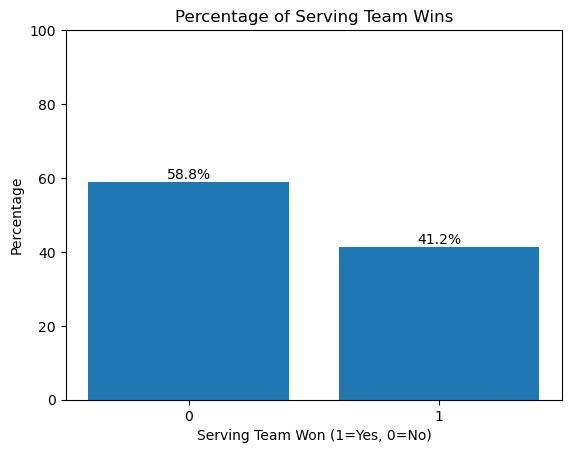

In [93]:
import matplotlib.pyplot as plt

percentages = rally_ts['srv_team_won'].value_counts(normalize=True) * 100
plt.bar(percentages.index.astype(str), percentages.values)
plt.title('Percentage of Serving Team Wins')
plt.xlabel('Serving Team Won (1=Yes, 0=No)')
plt.ylabel('Percentage')
for i, v in enumerate(percentages.values):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')
plt.ylim(0, 100)
plt.show()


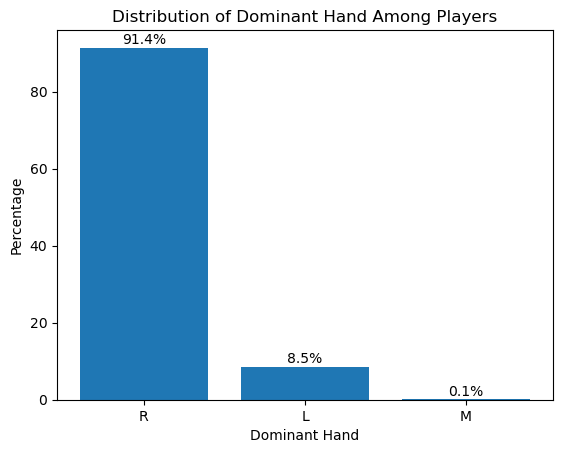

In [94]:
# Find the percentages of left and right handed players from the player df 
# Build a bar chart to show the distribution of dominant hand among players
dom_hand_counts = player['dom_hand'].value_counts(normalize=True) * 100
plt.bar(dom_hand_counts.index, dom_hand_counts.values)
plt.title('Distribution of Dominant Hand Among Players')
plt.xlabel('Dominant Hand')
plt.ylabel('Percentage')
for i, v in enumerate(dom_hand_counts.values):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')
plt.show()

# Begin training the models 

In [95]:
# Rename the rally_ts dataframe to model_df for clarity
model_df = rally_ts.copy()

In [96]:
# Peview the columns in model_df
model_df.columns

Index(['rally_id', 'rally_nbr', 'srv_team_id', 'srv_player_id', 'rtrn_team_id',
       'rtrn_player_id', 'ts_player_id', 'ts_type', 'w_team_id', 'rally_len',
       'srv_switch_ind', 'rtrn_switch_ind', 'srv_team_flipped_ind',
       'rtrn_team_flipped_ind', 'srv_team_rs_player_id',
       'srv_team_ls_player_id', 'rtrn_team_rs_player_id',
       'rtrn_team_ls_player_id', 'srv_team_rs_player_id_gender',
       'srv_team_rs_player_id_dom_hand', 'srv_team_ls_player_id_gender',
       'srv_team_ls_player_id_dom_hand', 'rtrn_team_rs_player_id_gender',
       'rtrn_team_rs_player_id_dom_hand', 'rtrn_team_ls_player_id_gender',
       'rtrn_team_ls_player_id_dom_hand', 'loc_x', 'loc_y', 'btt_before',
       'srv_team_won'],
      dtype='object')

In order to evaluate which shot should be selected we will filter to only include where the serving team wins and then predict the ts_type. That leads to that win. This model than then me implements in simulation for a team to develop a strategy around. 

In [97]:
#Drop all records with missing values from the model_df
model_df = model_df.dropna()


# find missing values that are 'NaN'
missing_percentage = model_df.isnull().mean() * 100
missing_percentage

rally_id                           0.0
rally_nbr                          0.0
srv_team_id                        0.0
srv_player_id                      0.0
rtrn_team_id                       0.0
rtrn_player_id                     0.0
ts_player_id                       0.0
ts_type                            0.0
w_team_id                          0.0
rally_len                          0.0
srv_switch_ind                     0.0
rtrn_switch_ind                    0.0
srv_team_flipped_ind               0.0
rtrn_team_flipped_ind              0.0
srv_team_rs_player_id              0.0
srv_team_ls_player_id              0.0
rtrn_team_rs_player_id             0.0
rtrn_team_ls_player_id             0.0
srv_team_rs_player_id_gender       0.0
srv_team_rs_player_id_dom_hand     0.0
srv_team_ls_player_id_gender       0.0
srv_team_ls_player_id_dom_hand     0.0
rtrn_team_rs_player_id_gender      0.0
rtrn_team_rs_player_id_dom_hand    0.0
rtrn_team_ls_player_id_gender      0.0
rtrn_team_ls_player_id_do

In [98]:
# Remove rally length column because it is not realistic to include in the model. 
model_df = model_df.drop(columns=['rally_len'])

# show the shape of the model_df
model_df.shape

(47259, 29)

In [99]:
# Drop the record if there is a column value = 'NaN'
model_df = model_df.replace('NaN', pd.NA).dropna()


In [100]:
# Filter the model_df to only include winning serving team records
model_df = model_df[model_df['srv_team_won'] == 1]

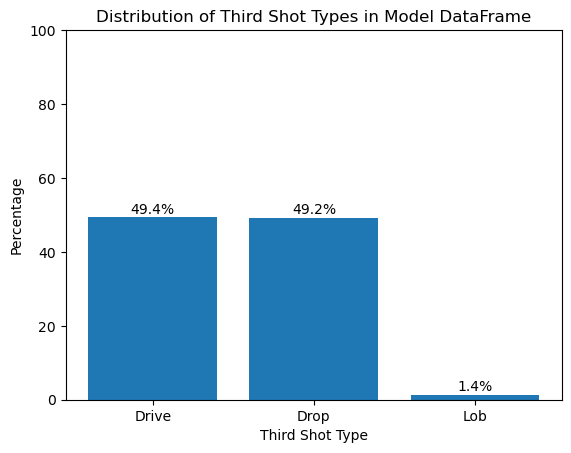

In [120]:
# Build a bar graph showing the distribution of ts_type in the model_df
ts_type_counts = model_df['ts_type'].value_counts(normalize=True) * 100
plt.bar(ts_type_counts.index, ts_type_counts.values)
plt.title('Distribution of Third Shot Types in Model DataFrame')
plt.xlabel('Third Shot Type')
plt.ylabel('Percentage')
for i, v in enumerate(ts_type_counts.values):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')
plt.ylim(0, 100)
plt.show()

In [114]:
# Create a train test split.
# Import packages.
import pandas as pd
from sklearn.model_selection import train_test_split
# create features
# Drop target variables and unnecessary columns
features = model_df.drop(columns=['rally_id', 'w_team_id', 'ts_type']) 

#Get dummies for categorical variables
features = pd.get_dummies(features, drop_first=True)
target = model_df['ts_type']
# Split into 80 % training 20% test # use train_test_split
features_train, features_test, target_train, target_test= train_test_split(features,
target, test_size=0.2, random_state=42)


from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
target_train = le.fit_transform(target_train)
target_test = le.transform(target_test)

In [115]:
import numpy as np

# Check for NaNs in features_train
print("NaNs in features_train:", np.isnan(features_train).sum().sum())
print("NaNs in features_test:", np.isnan(features_test).sum().sum())

# Impute if any NaNs exist
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
features_train = imputer.fit_transform(features_train)
features_test = imputer.transform(features_test)



NaNs in features_train: 0
NaNs in features_test: 0


In [103]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
import xgboost as xgb
from sklearn.neural_network import MLPClassifier

# Logistic Regression Grid Search
lr_params = {'C': [0.01, 0.1, 1, 10], 'solver': ['liblinear', 'lbfgs']}
lr = LogisticRegression(max_iter=1000)
lr_grid = GridSearchCV(lr, lr_params, cv=3, scoring='accuracy')
lr_grid.fit(features_train, target_train)
lr_best = lr_grid.best_estimator_
lr_pred = lr_best.predict(features_test)
lr_acc = accuracy_score(target_test, lr_pred)
print(f"Best Logistic Regression Accuracy: {lr_acc:.3f}")

# Random Forest Grid Search
rf_params = {'n_estimators': [50, 100], 'max_depth': [None, 5, 10]}
rf = RandomForestClassifier(random_state=42)
rf_grid = GridSearchCV(rf, rf_params, cv=3, scoring='accuracy')
rf_grid.fit(features_train, target_train)
rf_best = rf_grid.best_estimator_
rf_pred = rf_best.predict(features_test)
rf_acc = accuracy_score(target_test, rf_pred)
print(f"Best Random Forest Accuracy: {rf_acc:.3f}")

# XGBoost Grid Search
xgb_params = {
    'n_estimators': [50, 100],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.1, 0.2]
}
xgb_clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_grid = GridSearchCV(xgb_clf, xgb_params, cv=3, scoring='accuracy')
xgb_grid.fit(features_train, target_train)
xgb_best = xgb_grid.best_estimator_
xgb_pred = xgb_best.predict(features_test)
xgb_acc = accuracy_score(target_test, xgb_pred)
print(f"Best XGBoost Accuracy: {xgb_acc:.3f}")

# MLPClassifier (Neural Network) Grid Search
mlp_params = {
    'hidden_layer_sizes': [(16,), (32,), (64,), (32, 16)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam'],
    'max_iter': [200]
}
mlp = MLPClassifier(random_state=42)
mlp_grid = GridSearchCV(mlp, mlp_params, cv=3, scoring='accuracy')
mlp_grid.fit(features_train, target_train)
mlp_best = mlp_grid.best_estimator_
mlp_pred = mlp_best.predict(features_test)
mlp_acc = accuracy_score(target_test, mlp_pred)
print(f"Best MLPClassifier Accuracy: {mlp_acc:.3f}")

# Print best model
accuracies = {
    'Logistic Regression': lr_acc,
    'Random Forest': rf_acc,
    'XGBoost': xgb_acc,
    'MLPClassifier': mlp_acc
}
best_model = max(accuracies, key=accuracies.get)
print(f"Best model: {best_model} with accuracy {accuracies[best_model]:.3f}")

/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_ite

Best Logistic Regression Accuracy: 0.677
Best Random Forest Accuracy: 0.677


/opt/anaconda3/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [15:07:26] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [15:07:29] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [15:07:32] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [15:07:35] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i

Best XGBoost Accuracy: 0.663


/opt/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_

Best MLPClassifier Accuracy: 0.649
Best model: Logistic Regression with accuracy 0.677


/opt/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


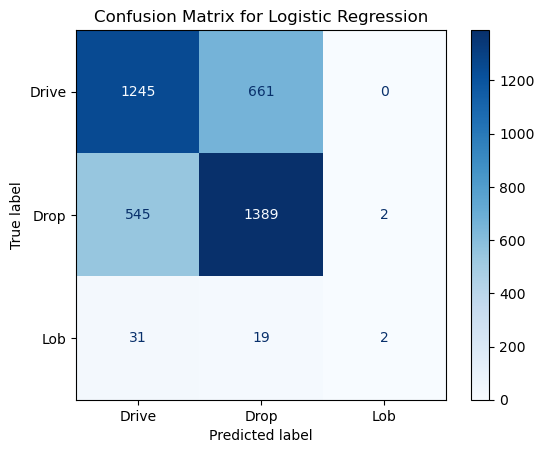

In [104]:
# SHow the confusion matrix for the best model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
if best_model == 'Logistic Regression':
    best_pred = lr_pred
elif best_model == 'Random Forest':
    best_pred = rf_pred
elif best_model == 'XGBoost':
    best_pred = xgb_pred
elif best_model == 'MLPClassifier':
    best_pred = mlp_pred
cm = confusion_matrix(target_test, best_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title(f'Confusion Matrix for {best_model}')
plt.show()

In [105]:
# Show the feature importance for the best model if applicable
if best_model in ['Random Forest', 'XGBoost']:
    if best_model == 'Random Forest':
        importances = rf_best.feature_importances_
    elif best_model == 'XGBoost':
        importances = xgb_best.feature_importances_
    feature_names = features.columns
    feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
    plt.figure(figsize=(10, 6))
    plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
    plt.xlabel('Importance')
    plt.title(f'Feature Importance for {best_model}')
    plt.gca().invert_yaxis()
    plt.show()
    

In [116]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
import xgboost as xgb
from sklearn.neural_network import MLPClassifier

# Logistic Regression Grid Search
lr_params = {'C': [0.01, 0.1, 1, 10], 'solver': ['liblinear', 'lbfgs']}
lr = LogisticRegression(max_iter=1000)
lr_grid = GridSearchCV(lr, lr_params, cv=3, scoring='accuracy')
lr_grid.fit(features_train, target_train)
lr_best = lr_grid.best_estimator_
lr_pred = lr_best.predict(features_test)
lr_acc = accuracy_score(target_test, lr_pred)
print(f"Best Logistic Regression Accuracy: {lr_acc:.3f}")

/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_ite

Best Logistic Regression Accuracy: 0.677


/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


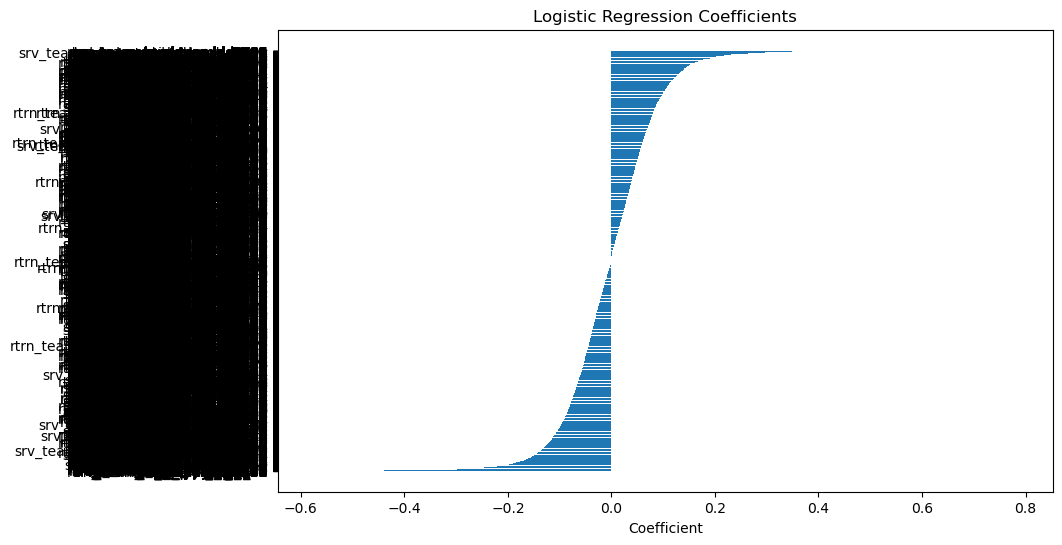

In [118]:
# Build coefecient plot for Logistic Regression if it is the best model
coef = lr_best.coef_[0]
feature_names = features.columns
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coef})
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)
plt.figure(figsize=(10, 6))
plt.barh(coef_df['Feature'], coef_df['Coefficient'])
plt.xlabel('Coefficient')
plt.title('Logistic Regression Coefficients')
plt.gca().invert_yaxis()
plt.show()

In [106]:
# Retrain the model not using the player or team IDs
# Create features without player or team IDs

# Create a train test split.
# Import packages.
import pandas as pd
from sklearn.model_selection import train_test_split
# create features
# Drop target variables and unnecessary columns
features = model_df.drop(columns=['ts_type','rally_id', 'w_team_id','srv_team_rs_player_id',
       'srv_team_ls_player_id', 'rtrn_team_rs_player_id',
       'rtrn_team_ls_player_id', 'srv_team_id', 'srv_player_id', 'rtrn_team_id', 'rtrn_player_id', 'ts_player_id']) 

#Get dummies for categorical variables
features = pd.get_dummies(features, drop_first=True)
target = model_df['ts_type']
# Split into 80 % training 20% test # use train_test_split
features_train, features_test, target_train, target_test= train_test_split(features,
target, test_size=0.2, random_state=42)


from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
target_train = le.fit_transform(target_train)
target_test = le.transform(target_test)

In [107]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
import xgboost as xgb
from sklearn.neural_network import MLPClassifier

# Logistic Regression Grid Search
lr_params = {'C': [0.01, 0.1, 1, 10], 'solver': ['liblinear', 'lbfgs']}
lr = LogisticRegression(max_iter=1000)
lr_grid = GridSearchCV(lr, lr_params, cv=3, scoring='accuracy')
lr_grid.fit(features_train, target_train)
lr_best = lr_grid.best_estimator_
lr_pred = lr_best.predict(features_test)
lr_acc = accuracy_score(target_test, lr_pred)
print(f"Best Logistic Regression Accuracy: {lr_acc:.3f}")

# Random Forest Grid Search
rf_params = {'n_estimators': [50, 100], 'max_depth': [None, 5, 10]}
rf = RandomForestClassifier(random_state=42)
rf_grid = GridSearchCV(rf, rf_params, cv=3, scoring='accuracy')
rf_grid.fit(features_train, target_train)
rf_best = rf_grid.best_estimator_
rf_pred = rf_best.predict(features_test)
rf_acc = accuracy_score(target_test, rf_pred)
print(f"Best Random Forest Accuracy: {rf_acc:.3f}")

# XGBoost Grid Search
xgb_params = {
    'n_estimators': [50, 100],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.1, 0.2]
}
xgb_clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_grid = GridSearchCV(xgb_clf, xgb_params, cv=3, scoring='accuracy')
xgb_grid.fit(features_train, target_train)
xgb_best = xgb_grid.best_estimator_
xgb_pred = xgb_best.predict(features_test)
xgb_acc = accuracy_score(target_test, xgb_pred)
print(f"Best XGBoost Accuracy: {xgb_acc:.3f}")

# MLPClassifier (Neural Network) Grid Search
mlp_params = {
    'hidden_layer_sizes': [(16,), (32,), (64,), (32, 16)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam'],
    'max_iter': [200]
}
mlp = MLPClassifier(random_state=42)
mlp_grid = GridSearchCV(mlp, mlp_params, cv=3, scoring='accuracy')
mlp_grid.fit(features_train, target_train)
mlp_best = mlp_grid.best_estimator_
mlp_pred = mlp_best.predict(features_test)
mlp_acc = accuracy_score(target_test, mlp_pred)
print(f"Best MLPClassifier Accuracy: {mlp_acc:.3f}")

# Print best model
accuracies = {
    'Logistic Regression': lr_acc,
    'Random Forest': rf_acc,
    'XGBoost': xgb_acc,
    'MLPClassifier': mlp_acc
}
best_model = max(accuracies, key=accuracies.get)
print(f"Best model: {best_model} with accuracy {accuracies[best_model]:.3f}")

/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_ite

Best Logistic Regression Accuracy: 0.531
Best Random Forest Accuracy: 0.568


/opt/anaconda3/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [16:24:17] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [16:24:17] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [16:24:17] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [16:24:17] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i

Best XGBoost Accuracy: 0.565


/opt/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_

Best MLPClassifier Accuracy: 0.562
Best model: Random Forest with accuracy 0.568


/opt/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


# Build simpler model with less features for amateur implementation. 

In [108]:
# Train again moving the location Data and the btt_bef
# ip players switched variables as this may be alot to process for a player in real time. 

# Create a train test split.
# Import packages.
import pandas as pd
from sklearn.model_selection import train_test_split
# create features
# Drop target variables and unnecessary columns
features = model_df.drop(columns=['ts_type','rally_id', 'w_team_id','srv_team_rs_player_id',
       'srv_team_ls_player_id', 'rtrn_team_rs_player_id',
       'rtrn_team_ls_player_id', 'srv_team_id', 'srv_player_id', 'rtrn_team_id', 'rtrn_player_id', 'ts_player_id', 'loc_x', 'loc_y', 
       'btt_before', 'srv_switch_ind', 'rtrn_switch_ind', 'srv_team_flipped_ind',
       'rtrn_team_flipped_ind']) 

#Get dummies for categorical variables
features = pd.get_dummies(features, drop_first=True)
target = model_df['ts_type']
# Split into 80 % training 20% test # use train_test_split
features_train, features_test, target_train, target_test= train_test_split(features,
target, test_size=0.2, random_state=42)


from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
target_train = le.fit_transform(target_train)
target_test = le.transform(target_test)


In [109]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
import xgboost as xgb
from sklearn.neural_network import MLPClassifier

# Logistic Regression Grid Search
lr_params = {'C': [0.01, 0.1, 1, 10], 'solver': ['liblinear', 'lbfgs']}
lr = LogisticRegression(max_iter=1000)
lr_grid = GridSearchCV(lr, lr_params, cv=3, scoring='accuracy')
lr_grid.fit(features_train, target_train)
lr_best = lr_grid.best_estimator_
lr_pred = lr_best.predict(features_test)
lr_acc = accuracy_score(target_test, lr_pred)
print(f"Best Logistic Regression Accuracy: {lr_acc:.3f}")

# Random Forest Grid Search
rf_params = {'n_estimators': [50, 100], 'max_depth': [None, 5, 10]}
rf = RandomForestClassifier(random_state=42)
rf_grid = GridSearchCV(rf, rf_params, cv=3, scoring='accuracy')
rf_grid.fit(features_train, target_train)
rf_best = rf_grid.best_estimator_
rf_pred = rf_best.predict(features_test)
rf_acc = accuracy_score(target_test, rf_pred)
print(f"Best Random Forest Accuracy: {rf_acc:.3f}")

# XGBoost Grid Search
xgb_params = {
    'n_estimators': [50, 100],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.1, 0.2]
}
xgb_clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_grid = GridSearchCV(xgb_clf, xgb_params, cv=3, scoring='accuracy')
xgb_grid.fit(features_train, target_train)
xgb_best = xgb_grid.best_estimator_
xgb_pred = xgb_best.predict(features_test)
xgb_acc = accuracy_score(target_test, xgb_pred)
print(f"Best XGBoost Accuracy: {xgb_acc:.3f}")

# MLPClassifier (Neural Network) Grid Search
mlp_params = {
    'hidden_layer_sizes': [(16,), (32,), (64,), (32, 16)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam'],
    'max_iter': [200]
}
mlp = MLPClassifier(random_state=42)
mlp_grid = GridSearchCV(mlp, mlp_params, cv=3, scoring='accuracy')
mlp_grid.fit(features_train, target_train)
mlp_best = mlp_grid.best_estimator_
mlp_pred = mlp_best.predict(features_test)
mlp_acc = accuracy_score(target_test, mlp_pred)
print(f"Best MLPClassifier Accuracy: {mlp_acc:.3f}")

# Print best model
accuracies = {
    'Logistic Regression': lr_acc,
    'Random Forest': rf_acc,
    'XGBoost': xgb_acc,
    'MLPClassifier': mlp_acc
}
best_model = max(accuracies, key=accuracies.get)
print(f"Best model: {best_model} with accuracy {accuracies[best_model]:.3f}")

/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_ite

Best Logistic Regression Accuracy: 0.524
Best Random Forest Accuracy: 0.538


/opt/anaconda3/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [16:25:36] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [16:25:37] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [16:25:37] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [16:25:37] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i

Best XGBoost Accuracy: 0.541
Best MLPClassifier Accuracy: 0.535
Best model: XGBoost with accuracy 0.541


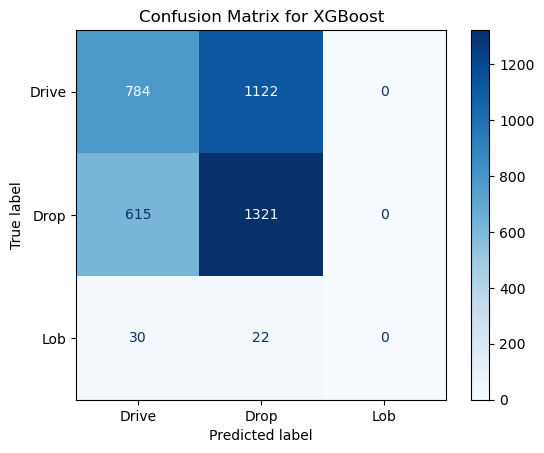

In [110]:
# SHow the confusion matrix for the best model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
if best_model == 'Logistic Regression':
    best_pred = lr_pred
elif best_model == 'Random Forest':
    best_pred = rf_pred
elif best_model == 'XGBoost':
    best_pred = xgb_pred
elif best_model == 'MLPClassifier':
    best_pred = mlp_pred
cm = confusion_matrix(target_test, best_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title(f'Confusion Matrix for {best_model}')
plt.show()

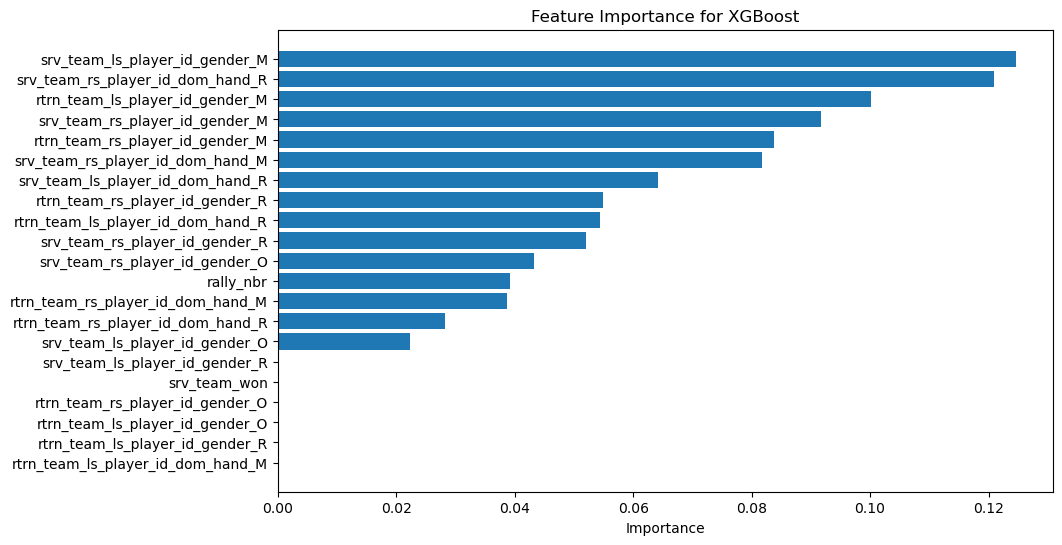

In [111]:
# Show the feature importance for the best model if applicable
if best_model in ['Random Forest', 'XGBoost']:
    if best_model == 'Random Forest':
        importances = rf_best.feature_importances_
    elif best_model == 'XGBoost':
        importances = xgb_best.feature_importances_
    feature_names = features.columns
    feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
    plt.figure(figsize=(10, 6))
    plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
    plt.xlabel('Importance')
    plt.title(f'Feature Importance for {best_model}')
    plt.gca().invert_yaxis()
    plt.show()